# Logistic Regression (From Scratch)

**File required:** `Social_Network_Ads.csv` (same folder as this notebook)

**Goal:** Predict whether a user **purchased** a product (`Purchased` = 1) from `Gender`, `Age` and `EstimatedSalary`, using a Logistic Regression model written by hand with NumPy.

### Key ideas
- Logistic regression is used for **classification**: the target is binary (0 or 1), not a continuous number.
- A straight line can't separate the classes well, so the linear output `z = w·x + b` is passed through the **sigmoid** function, which squeezes any number into the range 0–1 (a probability):

  `sigmoid(z) = 1 / (1 + e^(-z))`
- If the probability is greater than 0.5 the prediction is 1, otherwise 0.
- The weights are learned with **gradient descent**.

## Step 1 — Import libraries and load the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

data = pd.read_csv("Social_Network_Ads.csv")
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15571211,Male,38,76000,0
1,15813763,Male,41,83000,1
2,15719316,Male,35,57000,0
3,15747734,Male,28,105000,1
4,15594357,Male,33,77000,0


## Step 2 — Look at the sigmoid function

This shows why the output is "S" shaped and always between 0 and 1.

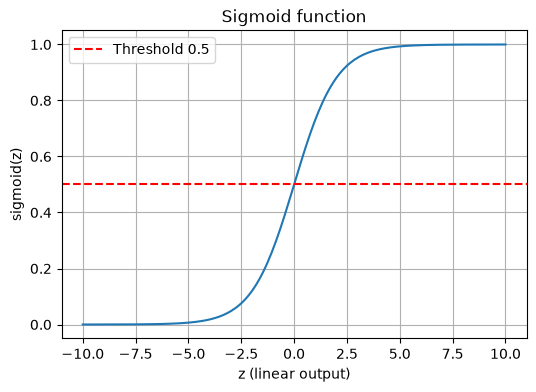

In [2]:
z = np.linspace(-10, 10, 200)
sig = 1 / (1 + np.exp(-z))

plt.figure(figsize=(6, 4))
plt.plot(z, sig)
plt.axhline(0.5, color="red", linestyle="--", label="Threshold 0.5")
plt.xlabel("z (linear output)")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid function")
plt.legend()
plt.grid(True)
plt.show()

## Step 3 — Preprocessing

`Gender` is text, so it is converted to numbers with one-hot encoding (`drop_first=True` keeps a single column, `Gender_Male`). Then the features `X` and the target `y` are defined.

In [3]:
data = pd.get_dummies(data, columns=["Gender"], drop_first=True, dtype=int)

X = data[["Gender_Male", "Age", "EstimatedSalary"]].values
y = data["Purchased"].values

print("X shape:", X.shape, " y shape:", y.shape)
data.head()

X shape: (400, 3)  y shape: (400,)


,User ID,Age,EstimatedSalary,Purchased,Gender_Male
0,15571211,38,76000,0,1
1,15813763,41,83000,1,1
2,15719316,35,57000,0,1
3,15747734,28,105000,1,1
4,15594357,33,77000,0,1


## Step 4 — Train/test split and feature scaling

Age (about 18–60) and salary (thousands) are on very different scales, which makes gradient descent slow and unstable. `StandardScaler` fixes this. The scaler learns from the training data only.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (320, 3)  Test: (80, 3)


## Step 5 — Logistic Regression implementation

Gradient descent repeats these steps `num_iterations` times:
1. `linear_model = X·w + b`
2. `y_predicted = sigmoid(linear_model)`
3. Gradients: `dw = (1/m) Xᵀ (y_predicted − y)` and `db = (1/m) Σ (y_predicted − y)`
4. Update: `w = w − lr·dw`, `b = b − lr·db`

The class also records the loss at every iteration so we can plot the learning progress.

In [5]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.lr = learning_rate
        self.iterations = num_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.weights = np.zeros(num_features)
        self.bias = 0

        for i in range(self.iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)

            # Update weights and bias by calculating Gradient
            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / num_samples) * np.sum(y_predicted - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Track the loss (log-loss) so we can plot learning progress
            eps = 1e-15
            loss = -np.mean(y * np.log(y_predicted + eps) + (1 - y) * np.log(1 - y_predicted + eps))
            self.loss_history.append(loss)

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return [1 if i > 0.5 else 0 for i in self.sigmoid(linear_model)]

## Step 6 — Train the model

In [6]:
model = LogisticRegression(learning_rate=0.1, num_iterations=1000)
model.fit(X_train, y_train)

print("Weights:", model.weights)
print("Bias   :", model.bias)

Weights: [0.19657024 1.81033933 1.12382637]
Bias   : -1.8798130302032112


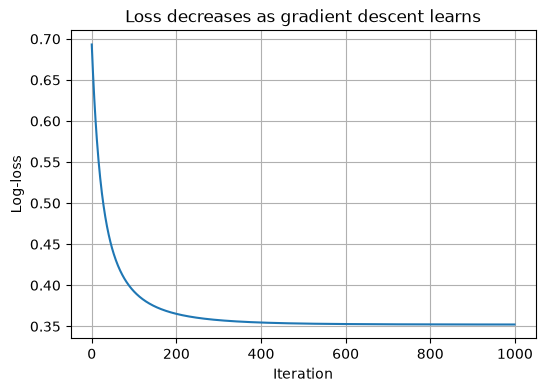

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(model.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Log-loss")
plt.title("Loss decreases as gradient descent learns")
plt.grid(True)
plt.show()

## Step 7 — Evaluate the model

In [8]:
predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, predictions))
print("Classification Report:\n", classification_report(y_test, predictions))

Accuracy: 0.85
Confusion Matrix:
 [[55  2]
 [10 13]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.96      0.90        57
           1       0.87      0.57      0.68        23

    accuracy                           0.85        80
   macro avg       0.86      0.77      0.79        80
weighted avg       0.85      0.85      0.84        80



### Interpretation
- The weights for **Age** and **EstimatedSalary** are positive: older users and users with higher salaries are more likely to purchase.
- `Gender_Male` has a much smaller weight than the other two, so gender has little effect here.
- The loss curve flattens out, which means gradient descent has converged.